# <span style="color:blue"> Computer Vision — Spring 2026

## Exercise 2

**Deadline:** May 6, 17:00. \
If you need more time, please send a private Piazza message letting me know that you'll submit late. An extension of up to 1 week is automatically approved.

---

In this exercise, you will implement:

1. Straight line detection from image features using Hough Transform.
2. Various feature matching.
3. Computing depth from rectified images.

## Submission guidelines

1. Your submission should include the following files:
   - `hw2_<ID>_<ID>.ipynb` \
     Replace \<ID\> with your ID number(s).
3. Use Jupyter Notebook.
4. Submit this assignment in pairs (no triplets, singles ok).
   * One student should submit the homework, and the other should not submit anything.
   * If you are not the one submitting, make sure that your collaborator indeed submits!
5. **Check that your solution is properly displayed in the last cell!**

## Read the following instructions carefully

1. Write **efficient vectorized** code.
2. You are responsible for the correctness of your code and should add as many tests as you see fit.
3. Use `Python 3` and `NumPy 1.3.2` or above. Before submitting the exercise, restart the kernel and run the notebook from start to finish to make sure everything works.
4. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/) and [NumPy](https://www.numpy.org/devdocs/reference/) only. Any other imports are forbidden unless provided by us.
5. Your code must run without errors. **Code that fails to run will not be graded.**
6. Document your code properly.

## Honor Code
The assignment is a basic tool for learning the material. You can probably find the solution on the web, but then you will not learn anything from it.
You are more than welcome to discuss the assignment with your friends, but you are not allowed to give your code or answers and you are not allowed to use their code or answers.
Feel free to use AI, but you are expected to understand every piece of code that you submit. Please re-read the course's AI policy.
Remember — you take this course in order to learn. Also, the final exam will contain a lot of material from the assignments. 😀

### I declair that I respcet the honor code, and that I understand the course's plagiarism policy and AI policy.
<span style="color:red"> \<Mendel Setti\>

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import null_space

%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots
plt.rcParams['image.cmap'] = 'gray'

import platform
print("Python version: ", platform.python_version())
print("Numpy version: ", np.__version__)

Python version:  3.12.12
Numpy version:  2.3.3


In [2]:
from pathlib import Path

# All images live in the images/ subfolder
example_image_path = Path("images/Sudoku.PNG")
example_img = cv2.imread(str(example_image_path), cv2.IMREAD_GRAYSCALE)

if example_img is None:
    print(f"Could not load image: {example_image_path}")
else:
    print(f"Loaded image: {example_image_path}, shape={example_img.shape}")

# Available images:
#   images/Sudoku.PNG, images/Crosswalk.jpg, images/linesOnTheRoadGray.jpg
#   images/view0.tif, images/view6.tif, images/view1.tif, images/view5.tif

Loaded image: images\Sudoku.PNG, shape=(1053, 1053)


## <span style="color:blue">Section A: Detect Straight Lines </span>

In this part you will use the set of edge points to detect straight lines in an image.\
The input will consist of edge points computed by the Canny edge detector - you can use the implementation of CV2, which is demonstrated below.\
The output will be a set of straight lines in the image. There are two main methods to compute straight lines from such input: the Hough transform and RANSAC. You will implement the Hough transform.

**Hough transform**\
Every 2D line, $\ell$, can be represented by 2 parameters: $r$ and $\theta$ where all points on the line satisfy $r= x\cos\theta + y\sin\theta$.
Let $P_0=(x_0,y_0)$ be the intersection of a normal to $\ell$ from the origin.
The distance between $P_0$ and the origin is given by $r$ and the angle between the normal and the $x$ axis is given by $\theta$.



**Your goal:**     Write the following function\
`straight_lines(image_file, resolution_r, resolution_ang, min_num_points, display, ...)`\
You may add other parameters; make sure to give them default values.
    


To do so, you need to also define the following functions. 
You may add parameters to the functions, as long as you provide clear explanations of their purpose.

In [ ]:
# Input: a set of edge points (or corners), and the resolution of the distance and angles.
# Output: the Hough matrix (H) containing votes for lines represented by r and theta.

def H_matrix(L_points, resolution_r, resolution_ang):
    x_max = max(L_points[:,0])
    y_max = max(L_points[:,1])
    max_distance = np.ceil(np.sqrt(x_max**2 + y_max**2))

    r_values = np.arange(-max_distance, max_distance + resolution_r, resolution_r)
    theta_values = np.arange(0, 180, resolution_ang)

    H = np.zeros((len(r_values), len(theta_values)), dtype=int)

    for point in L_points:
        for idx,theta in enumerate(theta_values):
            theta_rad = np.deg2rad(theta)
            r = point[0] * np.cos(theta_rad) + point[1] * np.sin(theta_rad)
            
            scale = np.around((r - r_values[0]) / resolution_r).astype(int)
            if 0 <= scale < H.shape[0]:
                H[scale, idx] += 1

    return H, r_values, theta_values

# Input: The Hough matrix H, and a threshold for the minimal number of points on the line.
# Output: a list of triplets (r, theta, num_points) where
# num_points is the number of points on that line.

def list_lines(H, r_val, theta_val, min_num_points):
    triplets = []
    for r_idx in range(H.shape[0]):
        for theta_idx in range(H.shape[1]):
            votes = H[r_idx,theta_idx]
            if votes >= min_num_points:
                r = r_val[r_idx]
                theta = theta_val[theta_idx]
                triplets.append((r, theta, votes))
    return triplets


# Display the detected lines in red - overlaid on the original image
def display_lines(im, lines):
    plt.figure(figsize=(8, 8))
    plt.imshow(im, cmap='gray')

    for r, theta, num_points in lines:
        theta_rad = np.deg2rad(theta)

        x0 = r * np.cos(theta_rad)
        y0 = r * np.sin(theta_rad)

        direction_x = -np.sin(theta_rad)
        direction_y = np.cos(theta_rad)

        distance = 1200

        x1 = int(x0 + distance * direction_x)
        x2 = int(x0 -distance * direction_x )

        y1 = int(y0 + distance * direction_y)
        y2 = int(y0 - distance * direction_y)

        point1 = (x1,y1)
        point2 = (x2,y2)
        #plt.plot(point1,point2,'-r',linewidth=2)
        plt.plot([x1, x2], [y1, y2], '-r', linewidth=2)
        
    plt.xlim([0, im.shape[1]])
    plt.ylim([im.shape[0], 0])   # flip y-axis to match image coordinates
    plt.title("Detected Hough Lines")
    plt.show()


In [23]:
# Now use the above functions to implement
def straight_lines(image_file, resolution_r, resolution_ang, min_num_points, display):
    img = cv2.imread(str(image_file),cv2.IMREAD_GRAYSCALE)

    # Corner Detection
    lower_treshold = 50
    higher_treshold = 150
    corners = cv2.Canny(img,lower_treshold,higher_treshold)

    rows, cols = np.where(corners>0)
    L_points = np.column_stack((cols,rows))

    # Hough Matrix
    hough_matrix, r_values, theta_values  = H_matrix(L_points,resolution_r,resolution_ang)

    # Lines
    lines = list_lines(hough_matrix, r_values, theta_values, min_num_points)

    # Display Lines
    if display:
        display_lines(img,lines)

    return hough_matrix,lines,corners,r_values,theta_values


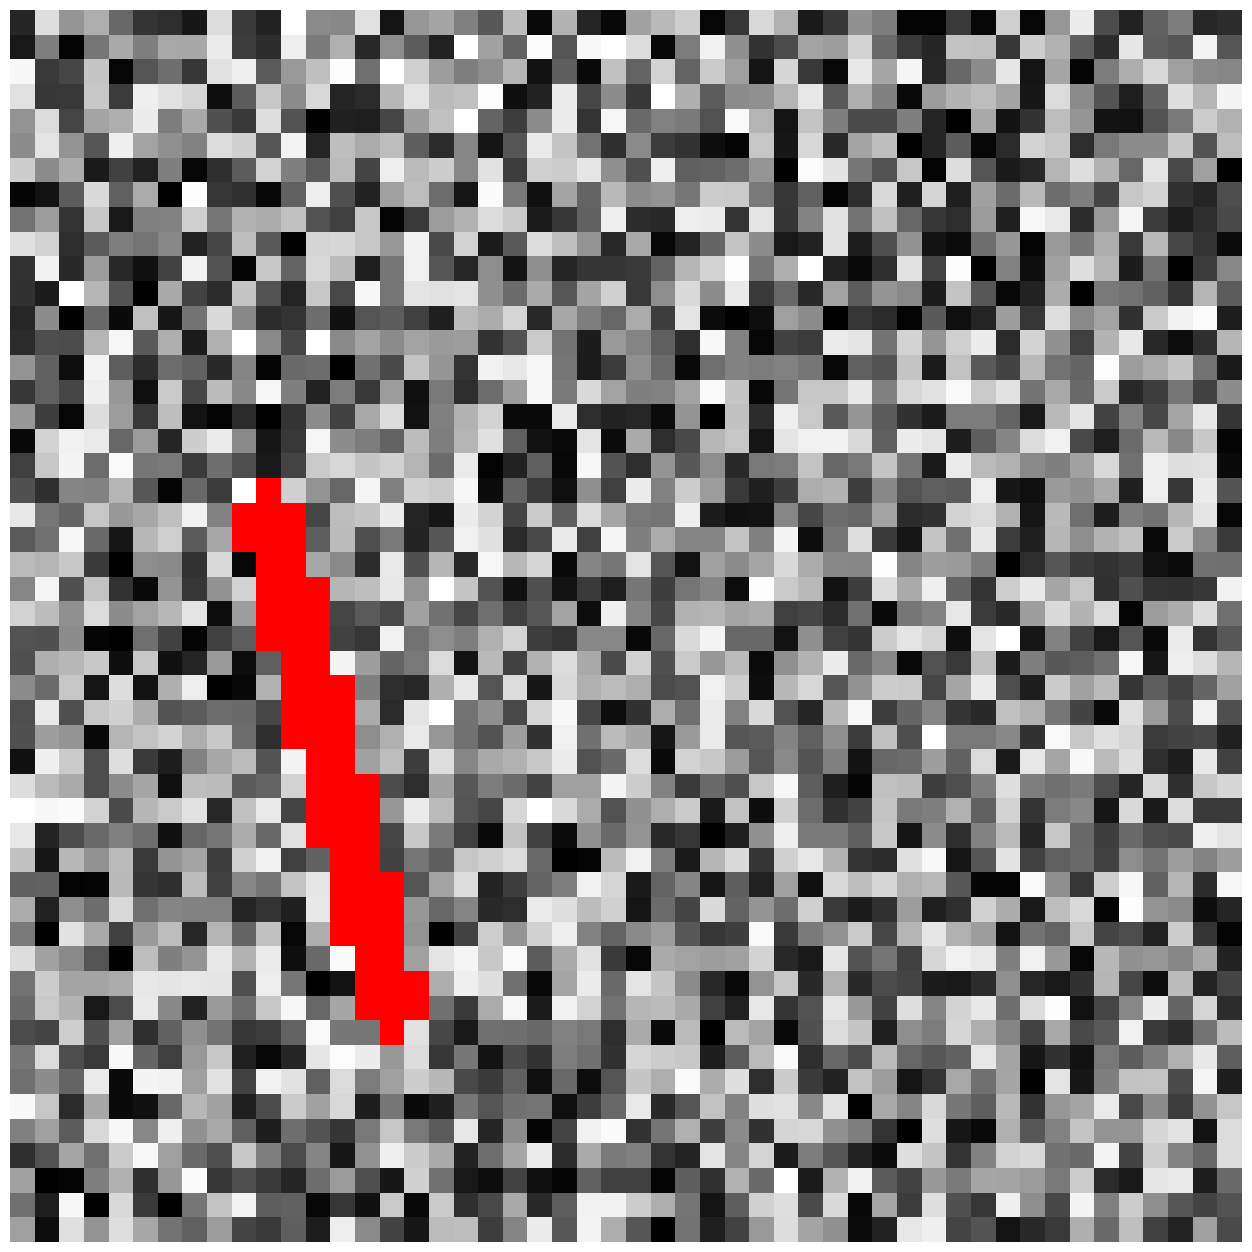

In [24]:
# Here is an example of how to draw a red line
# between (x1, y1) and (x2, y2) on a gray level image, img
# The first step is to create a color image from img.

img = np.random.randint(0, 256, size=(50, 50), dtype=np.uint8)
x1, y1 = 10, 20
x2, y2 = 15, 40
thickness = 2

color_image = np.dstack([img, img, img])
cv2.line(color_image, (x1, y1), (x2, y2), (255, 0, 0), thickness)

plt.imshow(color_image)
plt.axis('off')
plt.show()

(<matplotlib.image.AxesImage at 0x1b2e6b2b350>, Text(0.5, 1.0, 'Edge Image'))

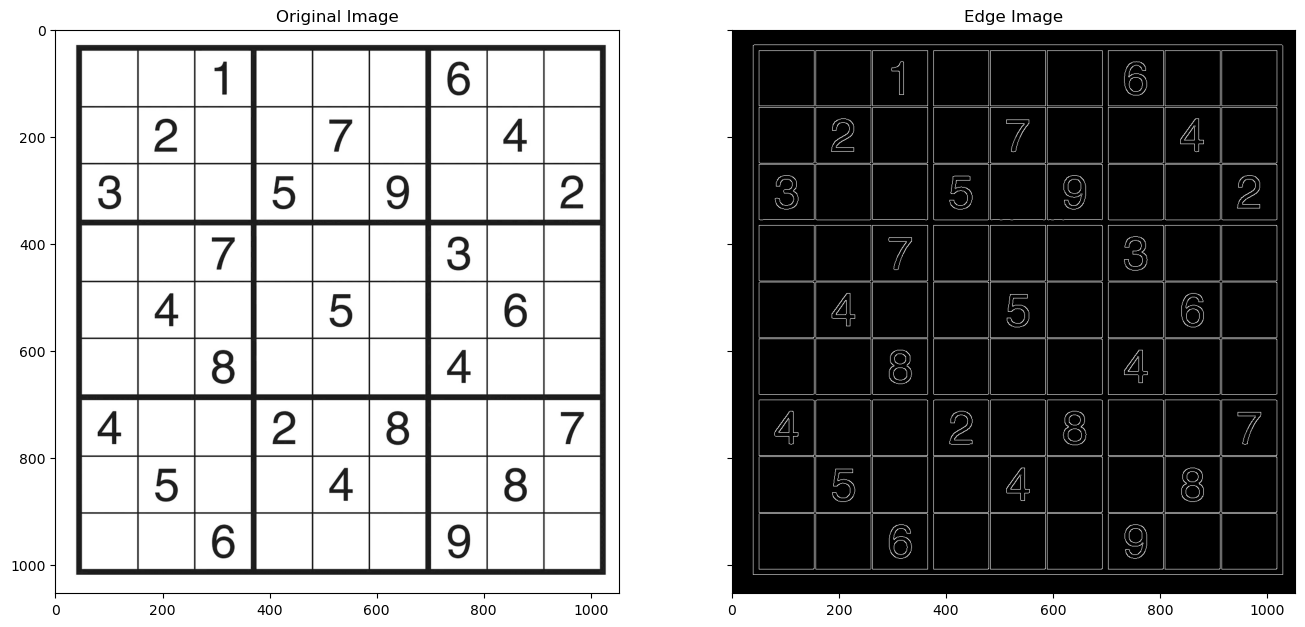

In [25]:
# Here is an example of how to use the CV2 Canny edge detector.
# You can play with the parameters to achieve desired results.

img = cv2.imread(str(Path("images/Sudoku.PNG")), cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

edges = cv2.Canny(img, 250, 500, 5)

plt.rcParams['figure.figsize'] = (16.0, 16.0)
f, (ax1, ax2) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(img), ax1.set_title('Original Image')
ax2.imshow(edges), ax2.set_title('Edge Image')


**Apply and answer**

1. Generate a synthetic image to test your Hough Transform algorithm. \
   Submit the image as well as the results.

2. Apply your algorithm to the following images: Crosswalk, linesOnTheRoadGray, Sudoku. \
   Choose an appropriate set of parameters; you might need different parameters for each image. Don't forget to display the results.
   
3. **Answer**: How the resolutions of $r$ and $\theta$ affect the results? Display images that demonstarte your answer.
   
4. Choose one image and **answer**: how many straight lines did you find with more than 50 points? Display these lines on the image.
   
5. Suggest an algorithm to compute the length of lines in the image. Describe the algorithm without implementing it.
   
6. Suggest three applications that use the results of straight line detection in an image.


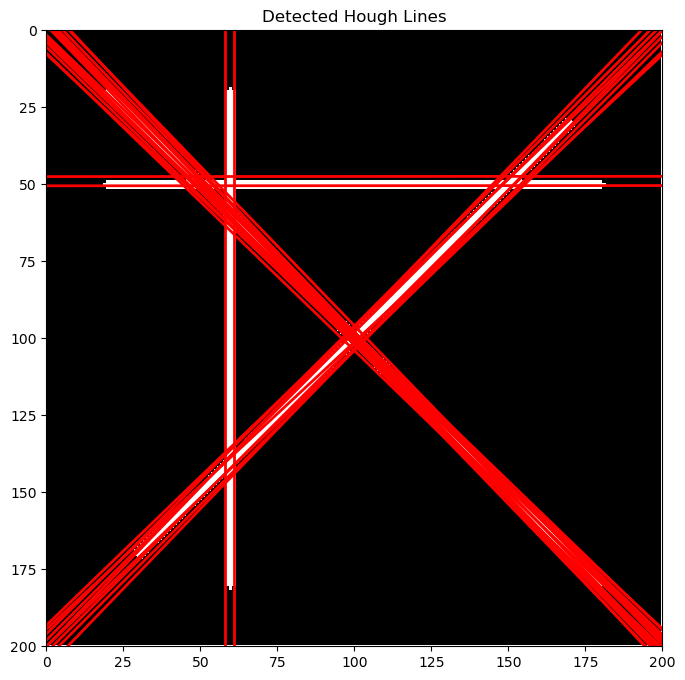


Detected lines:
r = -6.00, theta = 137.00, votes = 85
r = -5.00, theta = 136.00, votes = 86
r = -4.00, theta = 136.00, votes = 80
r = -3.00, theta = 136.00, votes = 87
r = -2.00, theta = 135.00, votes = 152
r = -2.00, theta = 136.00, votes = 98
r = -1.00, theta = 135.00, votes = 152
r = -1.00, theta = 136.00, votes = 80
r = 1.00, theta = 134.00, votes = 80
r = 1.00, theta = 135.00, votes = 152
r = 2.00, theta = 134.00, votes = 98
r = 2.00, theta = 135.00, votes = 152
r = 3.00, theta = 134.00, votes = 87
r = 4.00, theta = 134.00, votes = 80
r = 5.00, theta = 134.00, votes = 88
r = 6.00, theta = 133.00, votes = 85
r = 48.00, theta = 90.00, votes = 145
r = 51.00, theta = 90.00, votes = 146
r = 58.00, theta = 0.00, votes = 145
r = 61.00, theta = 0.00, votes = 146
r = 139.00, theta = 44.00, votes = 81
r = 139.00, theta = 45.00, votes = 136
r = 139.00, theta = 46.00, votes = 82
r = 140.00, theta = 45.00, votes = 130
r = 142.00, theta = 47.00, votes = 82
r = 143.00, theta = 45.00, votes = 13

'plt.figure(figsize=(6, 6))\nplt.imshow(im, cmap="gray")\nplt.title("Synthetic Test Image")\nplt.axis("off")\nplt.show()\n\nprint(expected_lines)'

In [26]:
# Synthetic Image Example

def create_synthetic_line_image(height=200, width=200, thickness=2):
    """
    Create a synthetic grayscale image with known straight lines.

    Output:
    - im: grayscale image
    - expected_lines: description of the lines drawn
    """

    im = np.zeros((height, width), dtype=np.uint8)

    # Draw known lines
    cv2.line(im, (20, 50), (180, 50), 255, thickness)      # horizontal line
    cv2.line(im, (60, 20), (60, 180), 255, thickness)      # vertical line
    cv2.line(im, (30, 170), (170, 30), 255, thickness)     # diagonal line
    cv2.line(im, (20, 20), (180, 180), 255, thickness)     # other diagonal line

    expected_lines = {
        "horizontal": "y = 50",
        "vertical": "x = 60",
        "diagonal_1": "roughly x + y = 200",
        "diagonal_2": "roughly y = x",
    }

    return im, expected_lines


im, expected_lines = create_synthetic_line_image()
cv2.imwrite("synthetic_lines.png", im)

# 3. Run your full Hough pipeline
H, lines, edges, r_values, theta_values = straight_lines(
    image_file="synthetic_lines.png",
    resolution_r=1,
    resolution_ang=1,
    min_num_points=80,
    display=True
)

# 4. Print detected lines
print("\nDetected lines:")
for r, theta, votes in lines:
    print(f"r = {r:.2f}, theta = {theta:.2f}, votes = {votes}")

'''plt.figure(figsize=(6, 6))
plt.imshow(im, cmap="gray")
plt.title("Synthetic Test Image")
plt.axis("off")
plt.show()

print(expected_lines)'''

In [ ]:
# Section A - Apply and answer (student code)
# TODO: student implementation

# lines_on_sudoku_overlay = ...  # colour image with detected lines on Sudoku
# resolution_effect = "..."
# line_length_algorithm = "..."
# line_detection_applications = ["...", "...", "..."]

## <span style="color:blue">Section B: Patch Matching </span>
**In this part you will match interest points across two images.**

There are two functions between vectors $v$ and $u$ that you will consider:\
a. Distance: Sum of Square Distance (SSD). That is,  $SSD(u,v)=(u-v)\cdot(u-v)$.\
b. Similarity: Normalized Cross Correlation (NCC). That is,  $NCC(u,v)={u\cdot v \over ||u||||v||}$.

The patch descriptor:
1. A vector with the pixels' grey level.
2. A histogram (30 bins) of the pixels' grey level.
3. A vector with the pixels' gradient strength.
4. A histogram (30 bins) of the pixels' gradient strength.

In [ ]:
# Implement the following functions:

# Input: two vectors
# Output: distance (scalar) between two patches
def SSD(patch_descr_1, patch_descr_2):
    if patch_descr_1.shape != patch_descr_2.shape:
        return "Vectors of differents length!"
    ssd = np.sum(np.square(patch_descr_1-patch_descr_2))
    return ssd

# Input: two vectors
# Output: normalized cross correlation (scalar) between two patches
def NCC(patch_descr_1, patch_descr_2):
    if patch_descr_1.shape != patch_descr_2.shape:
        return "Vectors of differents length!"
    numerator = patch_descr_1 @ patch_descr_2
    denominator = np.linalg.norm(patch_descr_1) * np.linalg.norm(patch_descr_2)
    result = numerator / denominator
    return result

# For the following, im is an image, p is a pixel location, size is the patch size.
# Output: a descriptor vector
# You can use the histogram function of open cv or numpy

def patch_from_im(im, p, size):
    window = size // 2
    row,col  = p
    if (row - window < 0 or row + window>= im.shape[0] or col - window < 0 or col+ window >= im.shape[1]):
        return "The window's size overflow the image"
    
    patch = im[row - window: row + window + 1,
               col - window: col + window +1 ]
    
    return patch.flatten()


def hist_patch_im(im, p, size):
    pixels = patch_from_im(im,p,size)
    bins = 30
    hist = cv2.calcHist(
        [pixels], # the image itself
        [0], # the channel for which we compute the histogram (0 for grayscale)
        None, # mask
        [bins], # number of bins
        [0, 256]) # range of pixel values 0-1 if normalized
    return hist

def gradient(im, p, size):
    # I am assuming that we can use the Sobel operator to compute the gradient of the patch
    patch = patch_from_im(im, p, size).reshape((size, size))
    # Compute gradients in x and y directions
    sobel_x = cv2.Sobel(patch, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(patch, cv2.CV_64F, 0, 1, ksize=3)
    return sobel_x, sobel_y

def hist_gradient(im, p, size):
    # TODO: student implementation
    raise NotImplementedError

**Apply and answer**
   
1. Compute the corners in a pair of images (e.g., `images/view0.tif` and `images/view6.tif`).
2. Experiment with 3 ways to perform the matching:
   1. Choose up to 2000 of the strongest corners (you can use fewer) and find a matching between the corners in the pair of images.
      - Choose a fixed scale and use it to define a patch around each corner.
      - To display the matching, use the function `cv2.hconcat([im1, im2])`, which concatenates two images horizontally, and then draw lines as described in the previous section.
   2. Use up to 4000 of the strongest corners (you can use fewer) in each image and use the matching only between corners that have approximately the same y-coordinate (up to a threshold). The `images` folder contains pairs of rectified images.
   3. Use the ratio between the best and second best matches to find good matches.
      - You can use NCC or SSD on the desriptor of your choice.
      - You can either apply or not apply the $y$-coordinate constraint (B).
      - **Present** examples that demonstrate the effectiveness of using the ratio.
3. Study the differences between the various descriptors and also the use of SSD or NCC. 
   - **Present**  examples that demonstrate your findings.
4. Identify incorrect pairs of matched points.
   **Mark and display** for cases (A), (B), and (C) a pair of incorrectly matched points.
   **Answer:**
   - In which of the 3 cases are there more incorrect matches?
   - What may be the reason for the incorrect matches?
5. In which regions of the scene were most of the reliable matches found?


In [ ]:
# Section B - Apply and answer (student code)
# TODO: student implementation

# match_overlay = ...    # color image showing matches (no y-constraint)
# match_overlay_y = ...  # color image showing matches (with y-constraint)
# matching_analysis = "..."
# reliable_match_regions = "..."

**Implementation details**

You can compute the NCC or SSD patch by patch. This will probably take longer than using matrix multiplications via NumPy.

Using matrices:
1. Generate a 1D vector from each descriptor.
2. Generate a matrix $M_1$:  rows  are  the descriptors of img1.
3. Generate a matrix $M_2$:  columns  are  the descriptors of img2.
4. Use `M = np.matmul(M_1,M_2)` or the shorthand `M = M_1 @ M_2` to multiple the matrices.
   * what is the value in $M(i,j)$?
5. Think of how to normalize `M` for NCC calculation, and how to use `M` for SSD calculation. \
Hint: consider the formula for $(a-b)^2$.
    
You can change the functions `SSD()` and `NCC()` above to use your vectorized implementation (i.e., their inputs should be matrices instead of vectors, where each column is one descriptor).

## <span style="color:blue">Section C: Extracting 3D Structure</span>

In this part you will compute the 3D structure from a pair of rectified images.


**Input:**
1. A pair of two rectified images, $im1$ and $im2$ (e.g., `images/view1.tif` and `images/view5.tif`).
2. A window size $(s_x,s_y$).
3. Disparity range $(d_{min},d_{max})$ (see below).

**Output:**
1. A matrix, $D$ with the disparity map for the left image.
2. Three matrices X, Y, Z with the x, y, z-coordinates of each pixel in the left image. Assign zero for pixels for which the disparity was not computed.

Note: all matrices $im1, im2, D, X, Y, Z$ have the same dimensions.

**Instructions:**
1. Your code should assume a pair of rectified images as input. You can use `images/view1.tif` and `images/view5.tif`.
2. Write a function that receives two rectified images, and computes dense matching along lines with the same $y$-coordinate.
    * You can use any of the descriptors from Part B. The patch size should be given as a parameter.
    * Use NCC for the similarity measure.
    * You can assume that you are given the range of disparities, $d_{min},d_{max}$ as an input. \
      For example, if  $(d_{min},d_{max})=(20,120)$ it follows that the corresponding point of  $(x,y)$ in the left image, is in the range $(x-120:x-20,y)$ in the right image.
    * Consider matching with and without order preserving. 
    * List all parameters you use for your function.
    * Hints on efficient implementation are given below.
3. Write a function that computes the disparity based on (2).  
    * **Display** the disparity $D$ map as an image
4. Compute the depth map using the disparity.
    * Assume that scaled focal lengths are $α_x=α_y=1$.
    * The distance between the cameras is 160mm.
    * Add to your disparity depth map the value 100, since images were cropped. 
    * Display the disparity as an image. 
5. Compute the matrices X,Y,Z
    * Present the object given by X,Y,Z using a 3D plot.


**Implementation**\
You can implement the computation of the similarity and the disparity directly by an exhaustive search. You can also use the idea from Part B. A more efficeint and elegant way is described below. You are welcome to try, but you do not have to.


General idea for the **vectorized solution** (you will need to fill in the gaps):
* Let $w$ and $h$ be the width and the height of the image respectively.
* First assume that the patch size is $1\times s_y$.
* Given two $1\times w$ rows, $r_1$ and $r_2$ which are corresponding rows of the two images. Compute the $w\times w$ matrix $R12=r_1^T r_2$. The values $R12(i,j)$ consists of the product of two pixels $r_1(i)\cdot r_2(j)$.
* Find a matrix that, when convolved with $R12$, will produce the correlation of the $s_y$ 1D neighborhood of $r_1(i)$ and $r_2(j)$.
* Think about how to normalize this correlation using the same ideas as in the previous section.
* Extend your solution to work for a general patch size $s_x\times s_y$. Hint: $R$ and the convolution kernels are no longer 2D matrices.
* Up to here, we considered each row seperately, hence we need to loop over all rows of the images. There is a way to do it without looping, but not in this assignemnt :)


In [ ]:
# Section C implementation area (student code)
# TODO: student implementation

###############################################################################
# IMPORTANT – Final variables for the Results Display cell.
# Define ALL of these somewhere in your notebook before running the last cell.
#
# Section A:
#   lines_on_sudoku_overlay  – colour image (H x W x 3) of Sudoku with detected lines drawn in red
#   resolution_effect        – string: how r and theta resolution affect results
#   line_length_algorithm    – string: algorithm to compute line length
#   line_detection_applications – list of 3 strings
#
# Section B:
#   match_overlay            – colour image (H x (W1+W2) x 3) showing matches between view0 & view6
#   match_overlay_y          – same as above but with y-coordinate constraint
#   matching_analysis        – string: analysis of incorrect matches
#   reliable_match_regions   – string: where reliable matches are found
#
# Section C:
#   disparity_map            – 2D array (H x W) disparity values
#   depth_map                – 2D array (H x W) depth values
###############################################################################

## Simple Submission Flow

1. Implement your code in Section A, Section B, and Section C cells.
2. Define the final variables listed below.
3. Run `Results Display` (last cell).
4. Submit this notebook (results are displayed at the end).

## Final Variables to Display

Define these variables in your notebook code. The last cell reads them directly.

**Section A – Hough Transform:**
- `lines_on_sudoku_overlay` – colour image (H x W x 3) of Sudoku with detected lines drawn in red
- `resolution_effect` (short text - answer to Q3)
- `line_length_algorithm` (short text - answer to Q5)
- `line_detection_applications` (list of 3 strings - answer to Q6)

**Section B – Patch Matching:**
- `match_overlay` – colour image showing matches between view0 & view6 (no y-constraint)
- `match_overlay_y` – colour image showing matches with y-coordinate constraint
- `matching_analysis` (short text - answer to Q4)
- `reliable_match_regions` (short text - answer to Q5)

**Section C – Stereo Depth:**
- `disparity_map` (2D array)
- `depth_map` (2D array)

## Final Results Display

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def _show_text(name, value):
    if value is None:
        print(f"  {name}: MISSING")
    else:
        print(f"  {name}: {value}")


def _show_image(name, value, figsize=(6, 5)):
    if value is None:
        print(f"  {name}: MISSING")
        return
    arr = np.asarray(value)
    print(f"  {name}: shape={arr.shape}, dtype={arr.dtype}")
    plt.figure(figsize=figsize)
    if arr.ndim == 2:
        plt.imshow(arr, cmap="gray")
    else:
        plt.imshow(arr)
    plt.title(name)
    plt.axis("off")
    plt.show()


# ==================== Section A ====================
print("=" * 60)
print("Section A - Hough Transform")
print("=" * 60)
_show_image("lines_on_sudoku_overlay",
            globals().get("lines_on_sudoku_overlay", None))
_show_text("resolution_effect",
           globals().get("resolution_effect", None))
_show_text("line_length_algorithm",
           globals().get("line_length_algorithm", None))
_show_text("line_detection_applications",
           globals().get("line_detection_applications", None))

# ==================== Section B ====================
print("\n" + "=" * 60)
print("Section B - Patch Matching")
print("=" * 60)
_show_image("match_overlay",
            globals().get("match_overlay", None), figsize=(14, 5))
_show_image("match_overlay_y",
            globals().get("match_overlay_y", None), figsize=(14, 5))
_show_text("matching_analysis",
           globals().get("matching_analysis", None))
_show_text("reliable_match_regions",
           globals().get("reliable_match_regions", None))

# ==================== Section C ====================
print("\n" + "=" * 60)
print("Section C - Depth from Stereo")
print("=" * 60)
disp = globals().get("disparity_map", None)
depth = globals().get("depth_map", None)
if disp is not None:
    arr = np.asarray(disp)
    print(f"  disparity_map: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={arr.min():.1f}, max={arr.max():.1f}")
    plt.figure(figsize=(8, 5))
    plt.imshow(arr, cmap="jet"); plt.colorbar(label="disparity")
    plt.title("disparity_map"); plt.axis("off"); plt.show()
else:
    print("  disparity_map: MISSING")
if depth is not None:
    arr = np.asarray(depth)
    print(f"  depth_map: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={arr.min():.1f}, max={arr.max():.1f}")
    plt.figure(figsize=(8, 5))
    plt.imshow(arr, cmap="jet"); plt.colorbar(label="depth (mm)")
    plt.title("depth_map"); plt.axis("off"); plt.show()
else:
    print("  depth_map: MISSING")